In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler


%matplotlib widget


In [2]:
condition = "2mod_hc"
checkpoint_epoch = 0
n_samples_test = 1000
split = "test"
dataset = "biased_00"

In [3]:
with total_silence():
    global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name =\
          get_modules_data_from_exp(
              experiment_name=condition,
              n_samples_test=n_samples_test,
              split=split,
              checkpoint_epoch=checkpoint_epoch)

original_images_rgb = visual_module.decode_images(original_data['v_latents'])
cat = original_data['attr'][0]


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


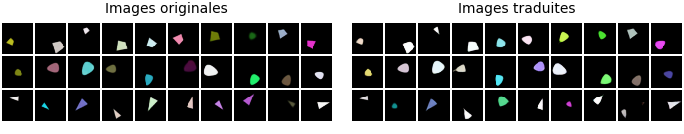

In [4]:
# cycle v latents through attr

gv = gw_mod.encode(latent_domains[frozenset({'v_latents'})])['v_latents']
x = gw_mod.decode(gv)
gva = gw_mod.encode(x)['attr']
v = gw_mod.decode(gva)['v_latents']

decoded_images= visual_module.decode_images(v)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images, cat, 10))
plt.show()


In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

colors_np = get_samples_rgb({"train_images": None, "images_decoded": decoded_images})
att = x['attr']
att_np = att.detach().cpu().numpy() if hasattr(att, 'numpy') else att

X_all = StandardScaler().fit_transform(att_np)

for label, X in [("tous les attributs", X_all)]:
    print(f"\n== {label} ==")
    for ch, name in enumerate(['R', 'G', 'B']):
        y = colors_np[:, ch]
        mlp = MLPRegressor(hidden_layer_sizes=(128, 128), max_iter=3000, random_state=42).fit(X, y)
        r2 = r2_score(y, mlp.predict(X))
        print(f"  R²_{name} = {r2:.4f}")

/home/lucas/gwsyn/syn_project/utils_color_analysis.py:122: UserWarning: Empty mask detected; using full image for color extraction
  warnings.warn("Empty mask detected; using full image for color extraction")



== tous les attributs ==
  R²_R = 0.9573
  R²_G = 0.9392
  R²_B = 0.9708


In [6]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

colors_np = get_samples_rgb({"train_images": None, "images_decoded": decoded_images})
att = x['attr']
att_np = att.detach().cpu().numpy() if hasattr(att, 'numpy') else att

X_all = StandardScaler().fit_transform(att_np)

for label, X in [("tous les attributs", X_all)]:
    print(f"\n== {label} ==")
    for ch, name in enumerate(['R', 'G', 'B']):
        y = colors_np[:, ch]
        mlp = MLPRegressor(hidden_layer_sizes=(128, 128), max_iter=3000, random_state=42).fit(X, y)
        r2 = r2_score(y, mlp.predict(X))
        print(f"  R²_{name} = {r2:.4f}")

/home/lucas/gwsyn/syn_project/utils_color_analysis.py:122: UserWarning: Empty mask detected; using full image for color extraction
  warnings.warn("Empty mask detected; using full image for color extraction")



== tous les attributs ==
  R²_R = 0.9573
  R²_G = 0.9392
  R²_B = 0.9708


In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np


X_all = StandardScaler().fit_transform(att_np)
n_attributes = att_np.shape[1]

def train_and_score(X):
    scores = []
    for ch in range(3):
        y = colors_np[:, ch]
        mlp = MLPRegressor(hidden_layer_sizes=(128, 128), max_iter=3000, random_state=42)
        mlp.fit(X, y)
        scores.append(r2_score(y, mlp.predict(X)))
    return np.mean(scores)

# Baseline : tous les attributs
baseline = train_and_score(X_all)
print(f"Baseline (tous) : R²_mean = {baseline:.4f}\n")

# 1. LEAVE-ONE-OUT : retire un attribut à la fois
print("== Leave-one-out ==")
print(f"{'Attribut retiré':>16} {'R²_mean':>10} {'Δ R²':>10}")
print("-" * 38)
loo_results = []
for i in range(n_attributes):
    cols = [j for j in range(n_attributes) if j != i]
    X_ablated = X_all[:, cols]
    score = train_and_score(X_ablated)
    delta = score - baseline
    loo_results.append((i, score, delta))

loo_results.sort(key=lambda x: x[2])  # les plus impactants en premier
for i, score, delta in loo_results:
    marker = " ***" if delta < -0.05 else (" *" if delta < -0.02 else "")
    print(f"{i:>16} {score:>10.4f} {delta:>+10.4f}{marker}")

# 2. KEEP-ONE-IN : un seul attribut à la fois
print("\n== Keep-one-in ==")
print(f"{'Seul attribut':>14} {'R²_mean':>10}")
print("-" * 26)
koi_results = []
for i in range(n_attributes):
    X_single = X_all[:, [i]]
    score = train_and_score(X_single)
    koi_results.append((i, score))

koi_results.sort(key=lambda x: x[1], reverse=True)
for i, score in koi_results:
    print(f"{i:>14} {score:>10.4f}")

Baseline (tous) : R²_mean = 0.9558

== Leave-one-out ==
 Attribut retiré    R²_mean       Δ R²
--------------------------------------
               7     0.8227    -0.1330 ***
               4     0.8363    -0.1195 ***
               5     0.8381    -0.1176 ***
               3     0.8571    -0.0986 ***
               6     0.8700    -0.0858 ***
               0     0.9278    -0.0280 *
               2     0.9379    -0.0179
               1     0.9480    -0.0077

== Keep-one-in ==
 Seul attribut    R²_mean
--------------------------
             5     0.2342
             2     0.0854
             1     0.0664
             3     0.0636
             7     0.0533
             0     0.0286
             4     0.0263
             6     0.0210


In [ ]:
from itertools import combinations

def top_n_sorted_by_index(results, n):
    # Trie par score décroissant, garde les n premiers, puis re-trie par index croissant
    top = sorted(results, key=lambda x: x[1], reverse=True)[:n]
    return sorted(idx for idx, _ in top)

candidates = top_n_sorted_by_index(koi_results, 5)

print(f"{'Attributs':>20} {'n':>3} {'R²_mean':>10}")
print("-" * 36)

all_combo_results = []
for n in range(2, 6):
    for combo in combinations(candidates, n):
        X_combo = X_all[:, list(combo)]
        score = train_and_score(X_combo)
        all_combo_results.append((list(combo), score))

# Affiche le meilleur de chaque taille
for n in range(2, 6):
    best = max([r for r in all_combo_results if len(r[0]) == n], key=lambda x: x[1])
    print(f"{str(best[0]):>20} {n:>3} {best[1]:>10.4f}")



           Attributs   n    R²_mean
------------------------------------
              [1, 5]   2     0.2971
           [1, 5, 7]   3     0.3742
        [1, 3, 5, 7]   4     0.4837
     [1, 2, 3, 5, 7]   5     0.6595


: 